# Profile Score — single-candidate desirability ranking

This notebook assigns **every candidate a single score** that ranks them on the strength of
*their own* profile, independent of any specific partner.

It is **not** the pairwise A×B compatibility in `matching_v2.ipynb`. Here the question is:
*"On their own merits, how strong / desirable is this dating profile?"*

**Design (decided with the team):**

- **Transparent weighted composite** — the score is a weighted sum of a few *named, interpretable*
  components. No model is trained; every score decomposes into "why".
- **Self-perception is excluded.** Self-ratings (`attr3_1` …) are subjective and self-flattering.
- **Instead we use *others' perception*** — how the candidate's actual speed-dating partners rated
  them (`attr_o, sinc_o, …` in the raw data), averaged across all their dates. This is an objective
  signal and the natural replacement for self-perception.
- Components: **Others' perception**, **Interest breadth & engagement**, **Openness / dating context**,
  **Flexibility**.
- **No validation** against `dec`/`match` — this notebook produces the score, the ranking, and a
  per-profile explanation only. (Others' perception is a *perception feature*, distinct from the
  yes/no decision outcome.)


In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "explainability_notebooks" else Path.cwd()
PROFILES_PATH = ROOT / "profiles" / "profiles_v2_llama3_1_8b.json"
RAW_CSV       = ROOT / "data" / "Speed Dating Data.csv"

# Canonical candidate set + display labels + bios come from the v2 profiles JSON.
with open(PROFILES_PATH) as f:
    PROFILES = json.load(f)
print(f"{len(PROFILES)} candidate profiles loaded")

# Numeric features come from the raw dataset (one participant repeats across their date rows).
raw = pd.read_csv(RAW_CSV, encoding="latin-1")
print(f"raw rows: {len(raw):,}  unique participants: {raw['iid'].nunique()}")

523 candidate profiles loaded
raw rows: 8,378  unique participants: 551


In [2]:
# 17 interest/hobby columns (1-10), same set used in profiles_v2 / matching_v2
HOBBIES = ["sports","tvsports","exercise","dining","museums","art","hiking","gaming",
           "clubbing","reading","tv","theater","movies","concerts","music","shopping","yoga"]

# How a candidate's PARTNERS rated them on each date (the "opposite perception").
# *_o = the other person's rating of this candidate; like_o = how much they liked them.
PERCEPTION_COLS = ["attr_o","sinc_o","intel_o","fun_o","amb_o","shar_o","like_o"]

# Context / flexibility inputs (constant per participant, repeated across rows).
CONTEXT_COLS = ["gender","age","go_out","date","exphappy","goal","imprace","imprelig"]

# goal code -> "seriousness / intent" on a 0-1 scale (Speed Dating key):
# 1 fun night, 2 meet people, 3 get a date, 4 serious relationship, 5 say I did it, 6 other
GOAL_SERIOUSNESS = {1: 0.40, 2: 0.60, 3: 0.70, 4: 1.00, 5: 0.30, 6: 0.50}

def _num(v):
    """float, or None for NaN/missing — keeps the math null-safe."""
    try:
        f = float(v)
        return None if f != f else f   # NaN check
    except (TypeError, ValueError):
        return None

In [3]:
# --- Others' perception: average each candidate's partner-ratings across all their dates ---
perception = raw.groupby("iid")[PERCEPTION_COLS].mean()

# --- Context / flexibility / interests: one value per candidate (mean collapses the repeats) ---
attrs = raw.groupby("iid")[CONTEXT_COLS + HOBBIES].mean()

features = attrs.join(perception)
print(f"per-candidate feature table: {features.shape[0]} rows x {features.shape[1]} cols")
features.head(3)

per-candidate feature table: 551 rows x 32 cols


,gender,age,go_out,date,exphappy,goal,imprace,imprelig,sports,tvsports,...,music,shopping,yoga,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o,like_o
iid,,,,,,,,,,,,,,,,,,,,,
1,0.0,21.0,1.0,7.0,3.0,2.0,2.0,4.0,9.0,2.0,...,9.0,8.0,1.0,6.7,7.4,8.0,7.2,8.000000,7.1,6.85
2,0.0,24.0,1.0,5.0,4.0,1.0,2.0,5.0,3.0,2.0,...,8.0,3.0,1.0,7.7,7.1,7.9,7.5,7.500000,6.5,7.60
3,0.0,25.0,1.0,3.0,4.0,6.0,8.0,4.0,3.0,8.0,...,5.0,8.0,7.0,6.5,7.1,7.3,6.2,7.111111,6.0,6.00


## The score

Each component is normalised to **0-1**. The total is a weighted average of whichever components
are available (missing components are dropped and the remaining weights renormalise), then scaled
to **0-100**.

| Component | What it rewards | Weight |
|---|---|---|
| **Perception** | High average ratings from real partners (attractive, sincere, intelligent, fun, ambitious, shared, liked) | **0.45** |
| **Interest** | Broad, engaged interests (many hobbies, rated highly) | **0.25** |
| **Openness** | Active, optimistic, intentional dater (goes out, expects to enjoy it, clearer goal) | **0.20** |
| **Flexibility** | Open to more partners (low same-race / same-religion requirement) | **0.10** |

The weights are a **documented prior, not learned** — edit `WEIGHTS` below and re-run to re-rank.
Perception carries the most weight because it is the only *objective* signal; the rest describe the
profile itself.

> **Why not age?** Age is shown in the ranking for context but is deliberately **not** a scoring
> term — turning age into desirability would bake in age bias.


In [4]:
WEIGHTS = {"perception": 0.45, "interest": 0.25, "openness": 0.20, "flexibility": 0.10}

def perception_score(r):
    """Mean of partner-given ratings (each 1-10), scaled to 0-1."""
    vals = [_num(r.get(c)) for c in PERCEPTION_COLS]
    vals = [v for v in vals if v is not None]
    if not vals:
        return None, {}
    detail = {c: _num(r.get(c)) for c in PERCEPTION_COLS}
    return statistics.mean(vals) / 10.0, detail

def interest_score(r):
    """Blend of engagement (how highly hobbies are rated) and breadth (how many are liked >=6)."""
    scores = [_num(r.get(h)) for h in HOBBIES]
    scores = [v for v in scores if v is not None]
    if not scores:
        return None, {}
    engagement = statistics.mean(scores) / 10.0
    breadth = sum(1 for s in scores if s >= 6) / len(scores)
    detail = {"engagement": round(engagement, 3), "breadth": round(breadth, 3),
              "hobbies_liked": sum(1 for s in scores if s >= 6), "hobbies_rated": len(scores)}
    return 0.5 * engagement + 0.5 * breadth, detail

def openness_score(r):
    """Active + optimistic + intentional dater."""
    parts, detail = [], {}
    go = _num(r.get("go_out"))           # 1 = several times a week ... 7 = almost never
    if go is not None:
        v = (7 - go) / 6.0               # invert: higher = goes out more
        parts.append(v); detail["goes_out"] = round(v, 3)
    exp = _num(r.get("exphappy"))        # 1-10 expected happiness
    if exp is not None:
        parts.append(exp / 10.0); detail["expected_happiness"] = round(exp / 10.0, 3)
    goal = _num(r.get("goal"))
    if goal is not None and int(goal) in GOAL_SERIOUSNESS:
        v = GOAL_SERIOUSNESS[int(goal)]
        parts.append(v); detail["goal_intent"] = v
    if not parts:
        return None, {}
    return statistics.mean(parts), detail

def flexibility_score(r):
    """Low same-race / same-religion requirement = open to more partners."""
    imps = [_num(r.get("imprace")), _num(r.get("imprelig"))]
    imps = [v for v in imps if v is not None]
    if not imps:
        return None, {}
    v = max(0.0, min(1.0, (10 - statistics.mean(imps)) / 10.0))
    return v, {"imprace": _num(r.get("imprace")), "imprelig": _num(r.get("imprelig"))}

COMPONENTS = {"perception": perception_score, "interest": interest_score,
              "openness": openness_score, "flexibility": flexibility_score}

def profile_score(r):
    """Return total (0-100) plus each component's normalised value and weighted contribution."""
    vals, details = {}, {}
    for name, fn in COMPONENTS.items():
        v, d = fn(r)
        vals[name] = v
        details[name] = d
    avail = {k: WEIGHTS[k] for k, v in vals.items() if v is not None}
    wsum = sum(avail.values())
    if not wsum:
        return {"score": None, "values": vals, "contrib": {}, "details": details}
    contrib = {k: 100 * WEIGHTS[k] * vals[k] / wsum for k in avail}
    return {"score": sum(contrib.values()), "values": vals, "contrib": contrib, "details": details}

In [5]:
import statistics  # used by the scoring functions above

rows = []
for iid_str, prof in PROFILES.items():
    iid = int(iid_str)
    if iid not in features.index:
        continue
    r = features.loc[iid]
    out = profile_score(r)
    if out["score"] is None:
        continue
    demo = prof.get("demographics", {})
    rows.append({
        "iid": iid,
        "gender": demo.get("gender"),
        "field": demo.get("field_of_study"),
        "age": demo.get("age"),
        "score": round(out["score"], 2),
        "perception": round(out["contrib"].get("perception", 0), 2),
        "interest":   round(out["contrib"].get("interest", 0), 2),
        "openness":   round(out["contrib"].get("openness", 0), 2),
        "flexibility":round(out["contrib"].get("flexibility", 0), 2),
    })

ranking = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
ranking.index += 1                      # 1-based rank
ranking.index.name = "rank"
print(f"scored {len(ranking)} candidates  |  score range "
      f"{ranking['score'].min():.1f} - {ranking['score'].max():.1f}")
ranking.head(15)

scored 523 candidates  |  score range 44.2 - 81.5


,iid,gender,field,age,score,perception,interest,openness,flexibility
rank,,,,,,,,,
1,19,Male,Business / Econ / Finance,28.0,81.52,34.14,18.38,20.00,9.0
2,346,Female,Unknown,NaN,77.94,77.94,0.00,0.00,0.0
3,20,Male,Business / Econ / Finance,24.0,77.92,35.29,20.29,13.33,9.0
4,250,Male,English / Creative Writing / Journalism,25.0,77.35,33.00,17.35,18.00,9.0
5,122,Male,Law,22.0,77.05,35.89,18.82,13.33,9.0
6,156,Female,Business / Econ / Finance,30.0,76.81,32.65,22.72,12.44,9.0
7,14,Male,Law,23.0,76.50,33.78,17.72,16.00,9.0
8,99,Male,Law,28.0,76.28,34.30,17.43,15.56,9.0
9,389,Female,Law,21.0,76.12,32.45,19.34,15.33,9.0


## Export the ranking (CSV / table)

`export_ranking()` writes the full ranked table to a CSV and returns it as a DataFrame.
Each row is one candidate with their rank, demographics, total score, the points each component
contributed, and (optionally) the raw 0-1 component values.

- `export_ranking("profile_scores.csv")` — all candidates
- `export_ranking("top50.csv", top=50)` — just the top 50
- `export_ranking("scores.csv", include_values=False)` — contributions only, no raw values

In [ ]:
def build_ranking(include_values=True):
    """Full ranked table: rank, ids, demographics, total score, per-component contributions,
    and (optionally) the raw 0-1 component values. One row per scored candidate."""
    rows = []
    for iid_str, prof in PROFILES.items():
        iid = int(iid_str)
        if iid not in features.index:
            continue
        out = profile_score(features.loc[iid])
        if out["score"] is None:
            continue
        demo = prof.get("demographics", {})
        row = {
            "iid": iid,
            "gender": demo.get("gender"),
            "field": demo.get("field_of_study"),
            "age": demo.get("age"),
            "score": round(out["score"], 2),
            "perception":  round(out["contrib"].get("perception", 0), 2),
            "interest":    round(out["contrib"].get("interest", 0), 2),
            "openness":    round(out["contrib"].get("openness", 0), 2),
            "flexibility": round(out["contrib"].get("flexibility", 0), 2),
        }
        if include_values:  # raw 0-1 component values (None where a component had no data)
            for name in COMPONENTS:
                v = out["values"][name]
                row[f"{name}_val"] = round(v, 3) if v is not None else None
        rows.append(row)
    df = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    df.insert(0, "rank", df.index + 1)
    return df


def export_ranking(path="profiles/profile_scores.csv", top=None, include_values=True):
    """Write the ranking to a CSV and return the DataFrame.

    path           : output CSV file (relative to this notebook's folder)
    top            : keep only the top-N rows (None = all candidates)
    include_values : also write the raw 0-1 component values, not just contributions
    """
    df = build_ranking(include_values=include_values)
    if top is not None:
        df = df.head(top)
    df.to_csv(path, index=False)
    print(f"wrote {len(df)} rows x {df.shape[1]} cols -> {path}")
    return df


# Save the full ranking and preview the table
scores_table = export_ranking("profile_scores.csv")
scores_table.head(20)

wrote 523 rows x 14 cols -> profile_scores.csv


,rank,iid,gender,field,age,score,perception,interest,openness,flexibility,perception_val,interest_val,openness_val,flexibility_val
0,1,19,Male,Business / Econ / Finance,28.0,81.52,34.14,18.38,20.00,9.0,0.759,0.735,1.000,0.90
1,2,346,Female,Unknown,NaN,77.94,77.94,0.00,0.00,0.0,0.779,NaN,NaN,NaN
2,3,20,Male,Business / Econ / Finance,24.0,77.92,35.29,20.29,13.33,9.0,0.784,0.812,0.667,0.90
3,4,250,Male,English / Creative Writing / Journalism,25.0,77.35,33.00,17.35,18.00,9.0,0.733,0.694,0.900,0.90
4,5,122,Male,Law,22.0,77.05,35.89,18.82,13.33,9.0,0.798,0.753,0.667,0.90
5,6,156,Female,Business / Econ / Finance,30.0,76.81,32.65,22.72,12.44,9.0,0.725,0.909,0.622,0.90
6,7,14,Male,Law,23.0,76.50,33.78,17.72,16.00,9.0,0.751,0.709,0.800,0.90
7,8,99,Male,Law,28.0,76.28,34.30,17.43,15.56,9.0,0.762,0.697,0.778,0.90
8,9,389,Female,Law,21.0,76.12,32.45,19.34,15.33,9.0,0.721,0.774,0.767,0.90
9,10,328,Female,Education / Academia,30.0,75.16,31.71,19.78,14.67,9.0,0.705,0.791,0.733,0.90


## Explain a single candidate

Every score decomposes back into its drivers.

In [7]:
def explain(iid):
    """Print the score breakdown + raw drivers + the candidate's bio."""
    prof = PROFILES[str(iid)]
    r = features.loc[iid]
    out = profile_score(r)
    demo = prof.get("demographics", {})
    print(f"PROFILE SCORE  #{iid}  ({demo.get('gender')}, {demo.get('field_of_study')}, "
          f"age {demo.get('age')})")
    print("=" * 68)
    print(f"TOTAL: {out['score']:.1f} / 100\n")
    for name in COMPONENTS:
        v = out["values"][name]
        if v is None:
            print(f"  {name:<12} n/a (no data)"); continue
        print(f"  {name:<12} value {v:5.2f}  x weight {WEIGHTS[name]:.2f}"
              f"  ->  {out['contrib'][name]:5.1f} pts")
        print(f"               drivers: {out['details'][name]}")
    print()
    print("bio    :", prof.get("bio", "").strip())
    print("seeking:", prof.get("seeking", "").strip())

# Top, middle, and bottom of the ranking
explain(int(ranking.iloc[0]["iid"]))
print("\n")
explain(int(ranking.iloc[len(ranking)//2]["iid"]))

PROFILE SCORE  #19  (Male, Business / Econ / Finance, age 28.0)
TOTAL: 81.5 / 100

  perception   value  0.76  x weight 0.45  ->   34.1 pts
               drivers: {'attr_o': 7.7, 'sinc_o': 6.8, 'intel_o': 7.7, 'fun_o': 8.5, 'amb_o': 7.1, 'shar_o': 7.7, 'like_o': 7.6}
  interest     value  0.74  x weight 0.25  ->   18.4 pts
               drivers: {'engagement': 0.706, 'breadth': 0.765, 'hobbies_liked': 13, 'hobbies_rated': 17}
  openness     value  1.00  x weight 0.20  ->   20.0 pts
               drivers: {'goes_out': 1.0, 'expected_happiness': 1.0, 'goal_intent': 1.0}
  flexibility  value  0.90  x weight 0.10  ->    9.0 pts
               drivers: {'imprace': 1.0, 'imprelig': 1.0}

bio    : Late-night drives with the windows down are my happy place - especially after hiking up a mountain or crushing it on the golf course.
seeking: In all honesty, looks aren't everything to me; but when they're paired with brains and an adventurous spirit (hello shared sporting events), I'm in.


PRO

## Score distribution & contribution mix

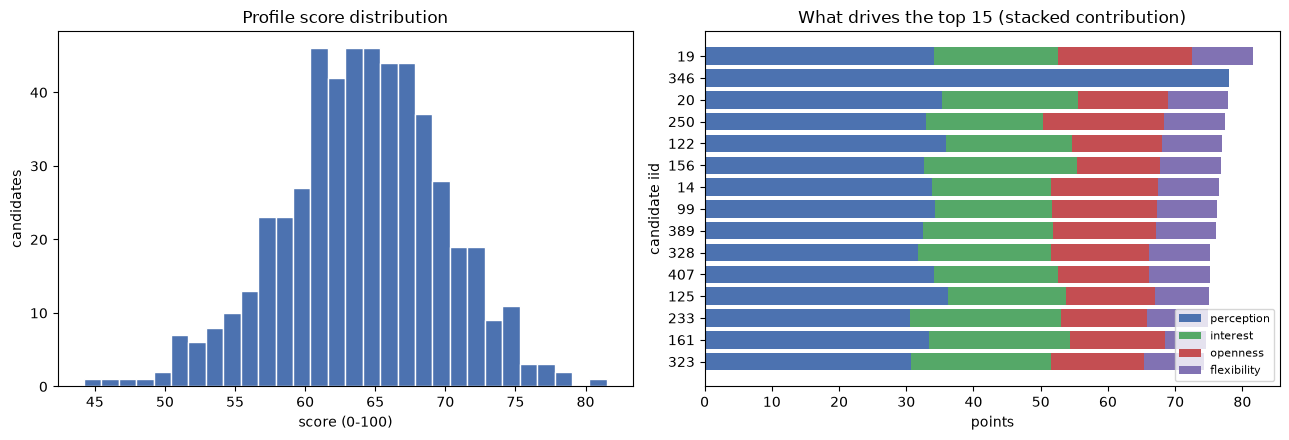

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.hist(ranking["score"], bins=30, color="#4C72B0", edgecolor="white")
ax1.set_title("Profile score distribution")
ax1.set_xlabel("score (0-100)"); ax1.set_ylabel("candidates")

top = ranking.head(15).iloc[::-1]
bottom = 0
for comp, color in [("perception", "#4C72B0"), ("interest", "#55A868"),
                    ("openness", "#C44E52"), ("flexibility", "#8172B3")]:
    ax2.barh(top["iid"].astype(str), top[comp], left=bottom, label=comp, color=color)
    bottom = bottom + top[comp].values
ax2.set_title("What drives the top 15 (stacked contribution)")
ax2.set_xlabel("points"); ax2.set_ylabel("candidate iid")
ax2.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

## Caveats

- **Others' perception** is defined for every candidate who actually attended (all 523 profiles), but
  it summarises how *that wave's* partners reacted — it is a perception feature, **not** the
  `dec`/`match` outcome, and the notebook does not validate against those labels.
- **Weights are a documented prior, not learned.** Re-weight `WEIGHTS` to reflect a different notion
  of "a strong profile" and re-run.
- **Age is descriptive only**, never a scoring term, to avoid encoding age bias.
- The score ranks profiles *on their own merits*; pairing two people still needs the
  compatibility logic in `matching_v2.ipynb`.
